# 🍔 Trabajo Práctico Integrador: Pipeline ETL & Inteligencia de Mercado (Food Delivery)

**Módulo:** Python para Análisis de Datos (ETL)
**Instructor:** Christian Condori
**Alumno:** _Jian Franco Sanchez Ramirez_

## 📌 Contexto
Trabajo como Data Engineer / Analista BI para una startup de Food Delivery que quiere expandirse en Estados Unidos.
Antes de invertir en una ciudad, el CEO necesita entender **cómo operan los restaurantes que ya existen**: cuántos hay,
qué tan caros son y si un precio más alto significa realmente mejor calidad.

Para responder eso voy a construir un **pipeline ETL completo**:

1. **EXTRACT**: leo los dos archivos que me entregó el equipo de Web Scraping.
2. **TRANSFORM**: limpio, separo columnas, traduzco los símbolos de precio y filtro lo que no sirve.
3. **LOAD**: guardo el resultado limpio en una base de datos SQLite.
4. **BUSINESS INTELLIGENCE**: hago consultas SQL y gráficos para responder las 4 preguntas del CEO.




## ⚙️ Paso 0: Importar las librerías que voy a usar

Antes de tocar cualquier dato, importo todo lo que voy a necesitar:
- `pandas` para manejar tablas (DataFrames).
- `glob` para poder leer los 10 archivos de menús de una sola vez, sin escribir 10 líneas repetidas.
- `sqlalchemy` para crear la base de datos SQLite.
- `matplotlib` y `seaborn` para los gráficos.


In [ ]:
import pandas as pd
import glob
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns

# Buena resolucion para todos los gráficos del reporte
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 🔽 FASE 1: EXTRACT (Extracción y Diagnóstico)

El equipo de Web Scraping me dejó dos cosas en la carpeta `data/`:

- `restaurants.csv` → el catálogo maestro de restaurantes (un archivo).
- `restaurant_menus_parte_1.csv` ... `restaurant_menus_parte_10.csv` → el detalle de los platos, pero partido
  en **10 archivos** (para que cada archivo pese menos). Como todos tienen las mismas columnas,
  los voy a unir en un solo DataFrame usando `glob` (para encontrar los 10 nombres de archivo automáticamente)
  y `pd.concat` (para pegarlos uno debajo del otro).


In [ ]:
# Cargo el catálogo de restaurantes
df_restaurantes = pd.read_csv('/content/restaurants.csv')

# Busco automáticamente los 10 archivos de menús y los uno en un solo DataFrame
archivos_menu = sorted(glob.glob('/content/restaurant_menus_parte_*.csv'))
print(f"Encontré {len(archivos_menu)} archivos de menús:")
for f in archivos_menu:
    print("  -", f)

df_menus = pd.concat([pd.read_csv(f) for f in archivos_menu], ignore_index=True)

Encontré 10 archivos de menús:
  - /content/restaurant_menus_parte_1.csv
  - /content/restaurant_menus_parte_10.csv
  - /content/restaurant_menus_parte_2.csv
  - /content/restaurant_menus_parte_3.csv
  - /content/restaurant_menus_parte_4.csv
  - /content/restaurant_menus_parte_5.csv
  - /content/restaurant_menus_parte_6.csv
  - /content/restaurant_menus_parte_7.csv
  - /content/restaurant_menus_parte_8.csv
  - /content/restaurant_menus_parte_9.csv


### 🔍 Data Profiling (exploración inicial)


Antes de limpiar nada, quiero ver con qué estoy trabajando: cuántas filas y columnas tiene cada tabla,
qué tipo de dato tiene cada columna, y cuántos valores nulos (vacíos) hay. Esto me va a decir dónde tengo
que poner atención en la limpieza.


In [ ]:
print("=" * 60)
print("DF_RESTAURANTES")
print("=" * 60)
print("Dimensiones (filas, columnas):", df_restaurantes.shape)
print("\nTipos de dato por columna:")
print(df_restaurantes.dtypes)
print("\nValores nulos por columna:")
print(df_restaurantes.isnull().sum())


DF_RESTAURANTES
Dimensiones (filas, columnas): (63469, 11)

Tipos de dato por columna:
id                int64
position          int64
name             object
score           float64
ratings         float64
category         object
price_range      object
full_address     object
zip_code         object
lat             float64
lng             float64
dtype: object

Valores nulos por columna:
id                  0
position            0
name                0
score           28167
ratings         28167
category           85
price_range     10617
full_address      453
zip_code          517
lat                 0
lng                 0
dtype: int64


In [ ]:
print("=" * 60)
print("DF_MENUS")
print("=" * 60)
print("Dimensiones (filas, columnas):", df_menus.shape)
print("\nTipos de dato por columna:")
print(df_menus.dtypes)
print("\nValores nulos por columna:")
print(df_menus.isnull().sum())


DF_MENUS
Dimensiones (filas, columnas): (836350, 5)

Tipos de dato por columna:
restaurant_id     int64
category         object
name             object
description      object
price            object
dtype: object

Valores nulos por columna:
restaurant_id         0
category              0
name                  1
description      200324
price                 0
dtype: int64


**Lo que observo:**
- `df_restaurantes` tiene muchos nulos en `score`, `ratings` y `price_range` → son restaurantes que probablemente
  todavía no tienen suficientes reseñas. Los voy a filtrar en la limpieza.
- `df_menus` tiene algunos nulos en `description`, pero esa columna no la voy a usar para el análisis, así que no
  es un problema grave. `price` no tiene nulos, pero viene como texto (ej. `"15.99 USD"`), así que hay que convertirlo
  a número.


## 🔧 FASE 2: TRANSFORM (Ingeniería de Características y Limpieza)

Acá está el trabajo más largo. Lo voy a dividir en dos partes: primero limpio `df_restaurantes`, después `df_menus`,
y al final hago el cruce (merge) entre las dos tablas ya limpias.

### 2.1 Mapeo de precios (`$` → texto legible)

La columna `price_range` viene con símbolos de dólar (`$`, `$$`, `$$$`, `$$$$`). Para que el CEO  entienda el reporte, los traduzco a texto usando un diccionario y el método `.map()`.


In [ ]:
mapa_precios = {
    '$': 'Económico',
    '$$': 'Moderadamente caro',
    '$$$': 'Caro',
    '$$$$': 'Muy caro'
}

df_restaurantes['rango_de_precios'] = df_restaurantes['price_range'].map(mapa_precios)

# Algunos valores no entran con ninguna categoría del diccionario (datos sucios del scraping)
# o directamente no tenían precio informado. Los agrupo como "No especificado" para no perderlos.
df_restaurantes['rango_de_precios'] = df_restaurantes['rango_de_precios'].fillna('No especificado')

df_restaurantes[['price_range', 'rango_de_precios']].drop_duplicates()


,price_range,rango_de_precios
0,$,Económico
1,NaN,No especificado
5,$$,Moderadamente caro
15,$$$,Caro
1734,$$$$,Muy caro
45118,$$$$$$$$$$$$$$$$$,No especificado


### 2.2 Desanidado de la dirección (Split)

La columna `full_address` tiene todo junto: calle, ciudad, estado y código postal, separados por comas.
Por ejemplo: `"224 Daniel Payne Drive, Birmingham, AL, 35207"`.

Uso `.str.split(',', n=2, expand=True)` para partirla en **3 columnas nuevas**: `calle`, `ciudad` y `estado_zip`
(esta última se queda con "Estado, Código Postal" juntos, ya que la consigna pide 3 columnas y no 4).
Además, le aplico `.str.strip()` a `ciudad` porque después de partir por coma suelen quedar espacios en blanco
pegados (ej. `" Birmingham"` en vez de `"Birmingham"`), y eso puede arruinar los `GROUP BY` más adelante.


In [ ]:
direcciones = df_restaurantes['full_address'].str.split(',', n=2, expand=True)

df_restaurantes['calle'] = direcciones[0]
df_restaurantes['ciudad'] = direcciones[1].str.strip()
df_restaurantes['estado_zip'] = direcciones[2]

df_restaurantes[['full_address', 'calle', 'ciudad', 'estado_zip']].head()


,full_address,calle,ciudad,estado_zip
0,"224 Daniel Payne Drive, Birmingham, AL, 35207",224 Daniel Payne Drive,Birmingham,"AL, 35207"
1,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",1521 Pinson Valley Parkway,Birmingham,"AL, 35217"
2,"541-B Graymont Ave, Birmingham, AL, 35204",541-B Graymont Ave,Birmingham,"AL, 35204"
3,"1580 Montgomery Highway, Hoover, AL, 35226",1580 Montgomery Highway,Hoover,"AL, 35226"
4,"314 17th St N, Birmingham, AL, 35203",314 17th St N,Birmingham,"AL, 35203"


### 2.3 Filtro de calidad

El CEO no quiere restaurantes "fantasma" (sin reseñas todavía). Elimino los que tienen `score` nulo o en 0.
También estandarizo `category` a minúsculas, para que "Pizza" y "pizza" no se cuenten como cosas distintas
más adelante.


In [ ]:
filas_antes = df_restaurantes.shape[0]

df_restaurantes = df_restaurantes.dropna(subset=['score'])
df_restaurantes = df_restaurantes[df_restaurantes['score'] != 0]
df_restaurantes['category'] = df_restaurantes['category'].str.lower()

filas_despues = df_restaurantes.shape[0]
print(f"Filas antes del filtro de calidad: {filas_antes}")
print(f"Filas después del filtro de calidad: {filas_despues}")
print(f"Se eliminaron {filas_antes - filas_despues} restaurantes sin score válido")


Filas antes del filtro de calidad: 63469
Filas después del filtro de calidad: 35302
Se eliminaron 28167 restaurantes sin score válido


### 2.4 Limpieza de `df_menus`: precio como número

El precio viene como texto, por ejemplo `"15.99 USD"`. Tengo que:
1. Sacar el texto `" USD"`.
2. Reemplazar la coma decimal por punto (por si algún precio viene en formato `"15,99"`).
3. Convertir el resultado a número decimal (`float`).


In [ ]:
df_menus['price'] = (
    df_menus['price']
    .astype(str)
    .str.replace(' USD', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df_menus['price'] = pd.to_numeric(df_menus['price'], errors='coerce')

df_menus[['name', 'price']].head()


,name,price
0,Extra Large Meat Lovers,15.99
1,Extra Large Supreme,15.99
2,Extra Large Pepperoni,14.99
3,Extra Large BBQ Chicken &amp; Bacon,15.99
4,Extra Large 5 Cheese,14.99


Ahora elimino los ítems de menú que quedaron sin precio (nulos) o con precio en `0.0` (probablemente
errores de scraping, no platos gratis reales).


In [ ]:
filas_antes = df_menus.shape[0]

df_menus = df_menus.dropna(subset=['price'])
df_menus = df_menus[df_menus['price'] != 0.0]

filas_despues = df_menus.shape[0]
print(f"Filas antes: {filas_antes} | Filas después: {filas_despues}")
print(f"Se eliminaron {filas_antes - filas_despues} ítems de menú sin precio válido")


Filas antes: 836350 | Filas después: 798799
Se eliminaron 37551 ítems de menú sin precio válido


### 2.5 Optimización de memoria y cruce (Merge)

El CEO solo quiere analizar restaurantes **consolidados**, es decir, con más de 100 calificaciones (`ratings`).
Esto además me ayuda a no colapsar la memoria del servidor cuando cruce las tablas, porque reduzco mucho la
cantidad de restaurantes antes de hacer el merge (que multiplica filas).

Antes de cruzar, también renombro `name` y `category` de `df_menus` para que no choquen con las columnas
`name` y `category` que ya existen en `df_restaurantes`.


In [ ]:
df_restaurantes_filtrado = df_restaurantes[df_restaurantes['ratings'] > 100]

print(f"Restaurantes totales después de la limpieza: {df_restaurantes.shape[0]}")
print(f"Restaurantes 'consolidados' (más de 100 ratings): {df_restaurantes_filtrado.shape[0]}")

# Renombro para evitar columnas duplicadas al hacer el merge
df_menus = df_menus.rename(columns={'name': 'item_name', 'category': 'item_category'})

# INNER JOIN: solo me quedo con los platos de restaurantes que pasaron el filtro
df_master = pd.merge(
    df_restaurantes_filtrado,
    df_menus,
    left_on='id',
    right_on='restaurant_id',
    how='inner'
)

df_master = df_master.drop(columns=['restaurant_id'])

print(f"\ndf_master final: {df_master.shape[0]} filas, {df_master.shape[1]} columnas")
df_master.head()


Restaurantes totales después de la limpieza: 35302
Restaurantes 'consolidados' (más de 100 ratings): 8702

df_master final: 63221 filas, 19 columnas


,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng,rango_de_precios,calle,ciudad,estado_zip,item_category,item_name,description,price
0,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",Picked for you,Spring Roll,"Three rolls. Shrimps, sliced pork, vermicelli ...",6.99
1,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",Picked for you,Egg Roll,"Pork, carrot, bean thread noodles, and are wra...",6.50
2,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",Picked for you,Grilled Pork,Foot long.,9.50
3,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",Picked for you,House Special,"Rice noodle with steak, rare, flank, brisket, ...",10.95
4,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",Picked for you,Rice Noodle with Rare Steak,NaN,10.95


## 💾 FASE 3: LOAD (Carga a Base de Datos)

Ahora que tengo `df_master` limpio, lo guardo en una base de datos **SQLite** local llamada
`delivery_insights.db`. Uso `sqlalchemy` para crear el motor de conexión (`engine`) y el método
`.to_sql()` de Pandas para volcar la tabla, con el nombre `master_food_data`.

- `if_exists="replace"` → si vuelvo a correr el notebook, reemplaza la tabla en vez de duplicar los datos.
- `index=False` → no guardo el índice numérico de Pandas como si fuera una columna más.


In [ ]:
engine = create_engine('sqlite:///delivery_insights.db')

df_master.to_sql('master_food_data', engine, if_exists='replace', index=False)

print("Tabla 'master_food_data' cargada en delivery_insights.db ")


Tabla 'master_food_data' cargada en delivery_insights.db 


## 📊 FASE 4: BUSINESS INTELLIGENCE (Reporte al CEO)

Ahora me conecto a la base de datos que acabo de crear y respondo, con SQL + gráficos, las 4 preguntas
que me pidió el CEO.


### 🏙️ Pregunta 1: Penetración Geográfica

¿Cuáles son las 5 ciudades con más restaurantes consolidados?


In [ ]:
query_1 = """
SELECT ciudad, COUNT(DISTINCT id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY ciudad
ORDER BY cantidad_restaurantes DESC
LIMIT 5
"""

with engine.connect() as conn:
    top_ciudades = pd.read_sql(text(query_1), conn)

print(query_1)
top_ciudades



SELECT ciudad, COUNT(DISTINCT id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY ciudad
ORDER BY cantidad_restaurantes DESC
LIMIT 5



,ciudad,cantidad_restaurantes
0,Milwaukee,122
1,Seattle,119
2,Lynnwood,40
3,Everett,32
4,Bellevue,28


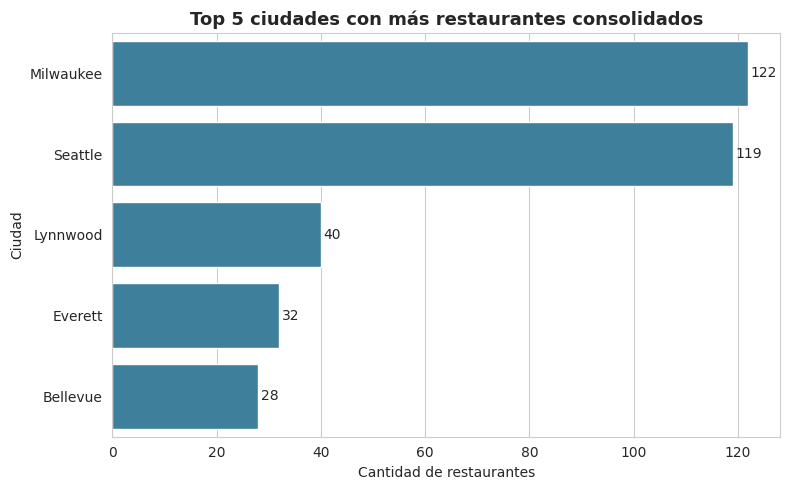

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=top_ciudades.sort_values('cantidad_restaurantes', ascending=False),
    x='cantidad_restaurantes', y='ciudad',
    color='#2E86AB', ax=ax
)
ax.set_title('Top 5 ciudades con más restaurantes consolidados', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de restaurantes')
ax.set_ylabel('Ciudad')
for i, v in enumerate(top_ciudades.sort_values('cantidad_restaurantes', ascending=False)['cantidad_restaurantes']):
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

**📌Conclusión para el CEO:** Las operaciones de los competidores están fuertemente concentradas en estas 5 ciudades, perfilándolas como los mercados iniciales más seguros para nuestra expansión.


### 💰 Pregunta 2: Análisis de Oportunidad de Precio
El CEO cree que todos los restaurantes del mercado son caros. Reviso la distribución real de `rango_de_precios`.


In [ ]:
query_2 = """
SELECT rango_de_precios, COUNT(DISTINCT id) AS cantidad
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY cantidad DESC
"""

with engine.connect() as conn:
    distribucion_precios = pd.read_sql(text(query_2), conn)

print(query_2)
distribucion_precios



SELECT rango_de_precios, COUNT(DISTINCT id) AS cantidad
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY cantidad DESC



,rango_de_precios,cantidad
0,Económico,450
1,Moderadamente caro,157
2,No especificado,60
3,Caro,4


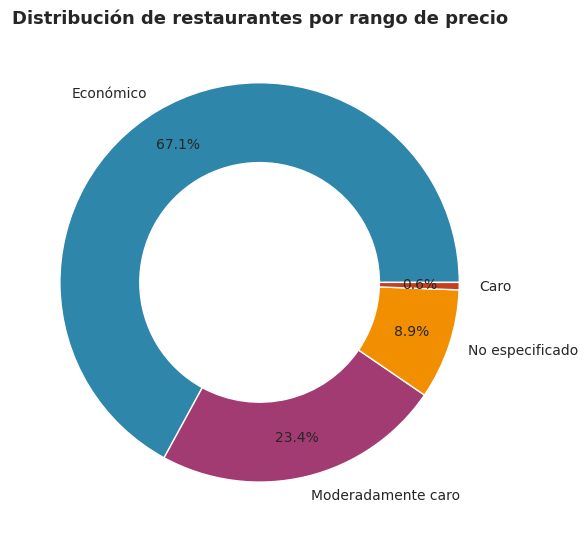

In [ ]:
colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#8D99AE']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    distribucion_precios['cantidad'],
    labels=distribucion_precios['rango_de_precios'],
    autopct='%1.1f%%',
    colors=colores,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4)  # esto lo convierte en donut chart
)
ax.set_title('Distribución de restaurantes por rango de precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**📌Conclusión para el CEO:** la percepción de que "todo es caro" no coincide con los datos: la gran mayoría
de los restaurantes consolidados están en la categoría "Económico". lo que representa una oportunidad para competir por volumen de ventas.


### 🍽️ Pregunta 3: Estrategia de Menú por Ciudad
Para las 3 ciudades más populares (de la Pregunta 1), calculo el precio promedio de los platos.


In [ ]:
top_3_ciudades = tuple(top_ciudades['ciudad'].head(3).tolist())
print("Top 3 ciudades:", top_3_ciudades)

query_3 = f"""
SELECT ciudad, AVG(price) AS precio_promedio
FROM master_food_data
WHERE ciudad IN {top_3_ciudades}
GROUP BY ciudad
ORDER BY precio_promedio DESC
"""

with engine.connect() as conn:
    precio_por_ciudad = pd.read_sql(text(query_3), conn)

print(query_3)
precio_por_ciudad


Top 3 ciudades: ('Milwaukee', 'Seattle', 'Lynnwood')

SELECT ciudad, AVG(price) AS precio_promedio
FROM master_food_data
WHERE ciudad IN ('Milwaukee', 'Seattle', 'Lynnwood')
GROUP BY ciudad
ORDER BY precio_promedio DESC



,ciudad,precio_promedio
0,Seattle,11.975071
1,Lynnwood,10.818490
2,Milwaukee,9.525836


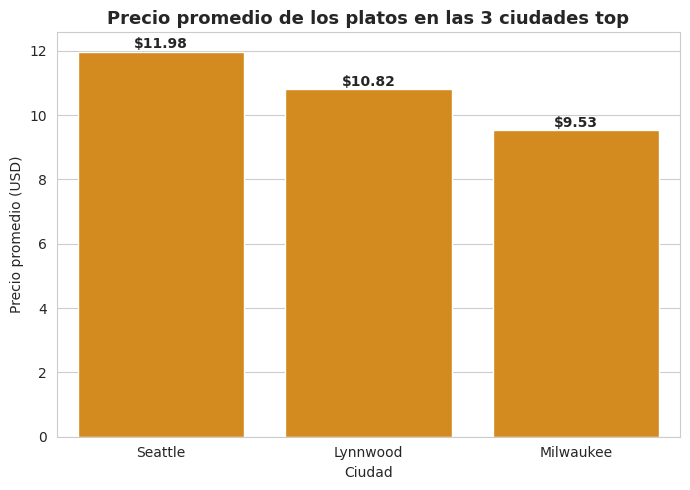

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=precio_por_ciudad, x='ciudad', y='precio_promedio', color='#F18F01', ax=ax)
ax.set_title('Precio promedio de los platos en las 3 ciudades top', fontsize=13, fontweight='bold')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Precio promedio (USD)')
for i, v in enumerate(precio_por_ciudad['precio_promedio']):
    ax.text(i, v + 0.1, f"${v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**📌Conclusión para el CEO:** Identificamos claramente en cuál de nuestros mercados top los usuarios gastan más por plato, permitiéndonos ajustar las comisiones de la app según la región.


### ⭐ Pregunta 4: Correlación Precio-Calidad
¿Pagar más garantiza mejor experiencia? Calculo el `score` promedio agrupado por `rango_de_precios`.


In [ ]:
query_4 = """
SELECT rango_de_precios, AVG(score) AS score_promedio
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY score_promedio DESC
"""

with engine.connect() as conn:
    score_por_precio = pd.read_sql(text(query_4), conn)

print(query_4)
score_por_precio



SELECT rango_de_precios, AVG(score) AS score_promedio
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY score_promedio DESC



,rango_de_precios,score_promedio
0,No especificado,4.625407
1,Moderadamente caro,4.615573
2,Económico,4.614091
3,Caro,4.433117


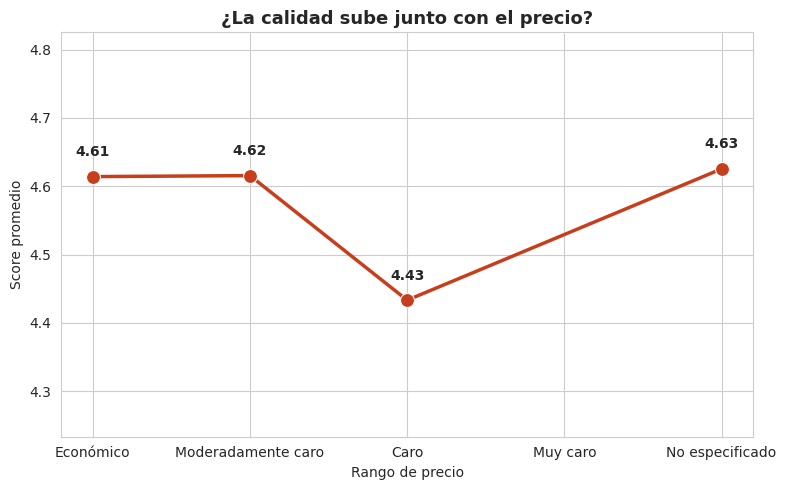

In [ ]:
orden_precios = ['Económico', 'Moderadamente caro', 'Caro', 'Muy caro', 'No especificado']
score_por_precio['rango_de_precios'] = pd.Categorical(
    score_por_precio['rango_de_precios'], categories=orden_precios, ordered=True
)
score_por_precio = score_por_precio.sort_values('rango_de_precios')

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=score_por_precio, x='rango_de_precios', y='score_promedio',
    marker='o', color='#C73E1D', linewidth=2.5, markersize=10, ax=ax
)
ax.set_title('¿La calidad sube junto con el precio?', fontsize=13, fontweight='bold')
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Score promedio')
ax.set_ylim(score_por_precio['score_promedio'].min() - 0.2, score_por_precio['score_promedio'].max() + 0.2)
for x, y in zip(score_por_precio['rango_de_precios'], score_por_precio['score_promedio']):
    ax.text(x, y + 0.03, f"{y:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Conclusión para el CEO:** el puntaje promedio se mantiene prácticamente igual entre los rangos de precio
(las diferencias son de centésimas), así que pagar más **no garantiza** una mejor experiencia: la calidad
percibida es casi independiente del precio.


## ✅ Conclusión general del proyecto

Con este pipeline logré:
1. Unificar y limpiar dos fuentes de datos crudas (restaurantes + más de 800 mil ítems de menú).
2. Reducir el dataset a los restaurantes realmente "consolidados" (más de 100 calificaciones) para no
   saturar la memoria.
3. Cargar todo en una base de datos SQL local, lista para que cualquier analista la consulte.
4. Responder con datos reales las 4 preguntas del CEO: dónde hay más competencia, si el mercado es tan caro
   como se creía, cómo varía el ticket promedio entre ciudades, y si el precio realmente predice calidad.

